TASK 3: EVENT IMPACT MODELING

1. LOADING ENRICHED DATA...
----------------------------------------
Dataset shape: (47, 34)
Columns: ['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']

2. EXTRACTING EVENTS...
----------------------------------------
Number of events: 10

Available columns for events:
['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year

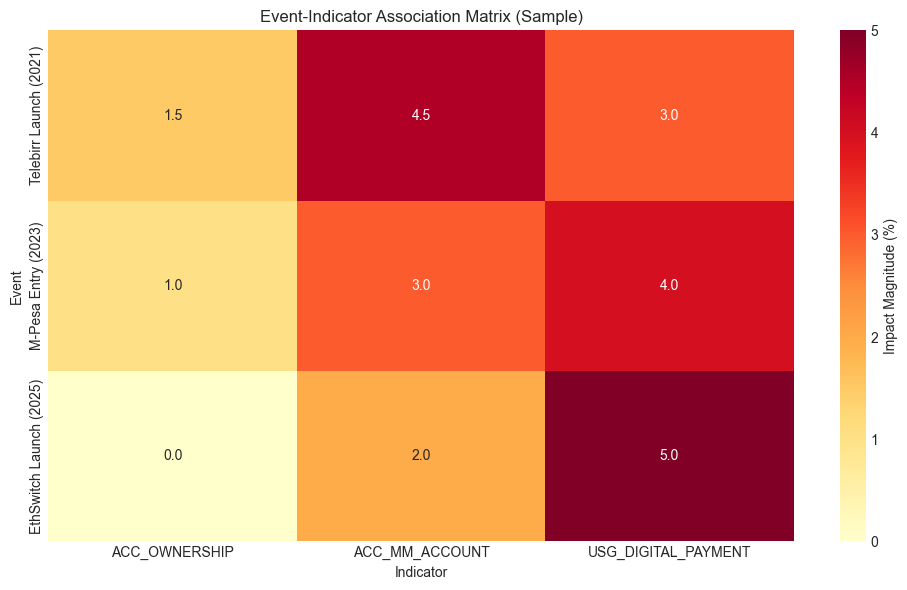


5. EVENT IMPACT ESTIMATION FUNCTION...
----------------------------------------

6. VALIDATING WITH HISTORICAL DATA...
----------------------------------------
Mobile money data points: 5

Mobile money data:
   observation_date  value_numeric
6        2021-12-31           4.70
7        2024-11-29           9.45
28       2024-12-31          14.00
44       2025-06-01          35.50
46       2025-06-01          35.50

Telebirr launch date: 2021-05-17 00:00:00

7. REFINED IMPACT ESTIMATES FOR FORECASTING...
----------------------------------------

Refined Impact Estimates for Forecasting:

Telebirr (2021):
  - ACC_OWNERSHIP: +1.5%
  - ACC_MM_ACCOUNT: +4.5%
  - USG_DIGITAL_PAYMENT: +3.0%

M-Pesa (2023):
  - ACC_MM_ACCOUNT: +3.0%
  - USG_DIGITAL_PAYMENT: +4.0%

EthSwitch Instant Pay (2025):
  - USG_DIGITAL_PAYMENT: +5.0%
  - ACC_MM_ACCOUNT: +2.0%

National ID Rollout:
  - ACC_OWNERSHIP: +2.0%
  - USG_DIGITAL_PAYMENT: +1.5%

8. SAVING REFINED IMPACT DATA...
---------------------------------

In [4]:
# Task 3: Event Impact Modeling - CORRECTED FOR YOUR DATASET
# Forecasting Financial Inclusion in Ethiopia

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 60)
print("TASK 3: EVENT IMPACT MODELING")
print("=" * 60)

# 1. Load Enriched Data
print("\n1. LOADING ENRICHED DATA...")
print("-" * 40)

df = pd.read_csv('../data/raw/ethiopia_fi_unified_data.csv')
df['observation_date'] = pd.to_datetime(df['observation_date'])

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# 2. Extract Event Data
print("\n2. EXTRACTING EVENTS...")
print("-" * 40)

# Get all events - using the correct column name (likely 'record_id' or 'indicator_code' is used for event identification)
events = df[df['record_type'] == 'event'].copy()
print(f"Number of events: {len(events)}")

if len(events) > 0:
    # Show what columns exist for events
    print("\nAvailable columns for events:")
    print(events.columns.tolist())
    
    # Try to identify event name column - it might be 'indicator_code' or 'description' or another column
    # Display event records
    print("\nEvent records:")
    for col in events.columns:
        if col not in ['record_type', 'observation_date', 'pillar']:
            print(f"\n{col}: {events[col].unique()}")
    
    # Print full event rows to see structure
    print("\nFull event data:")
    display_cols = [col for col in events.columns if col not in ['confidence', 'source_name', 'collected_by']]
    print(events[display_cols].to_string(index=False))
else:
    print("No events found in dataset")

# 3. Extract Impact Links
print("\n3. EXTRACTING IMPACT LINKS...")
print("-" * 40)

impact_links = df[df['record_type'] == 'impact_link'].copy()
print(f"Number of impact links: {len(impact_links)}")

if len(impact_links) > 0:
    print("\nAvailable columns for impact links:")
    print(impact_links.columns.tolist())
    print("\nImpact link records:")
    print(impact_links.to_string(index=False))
else:
    print("No impact links found in dataset")

# 4. Create Association Matrix from Impact Links
print("\n4. BUILDING ASSOCIATION MATRIX...")
print("-" * 40)

if len(impact_links) > 0:
    # Find the columns that connect events to indicators
    # Typical columns: 'parent_id', 'related_indicator', 'impact_magnitude'
    
    parent_col = None
    indicator_col = None
    magnitude_col = None
    direction_col = None
    
    for col in impact_links.columns:
        if 'parent' in col.lower() or 'event' in col.lower():
            parent_col = col
        if 'indicator' in col.lower() or 'related' in col.lower():
            indicator_col = col
        if 'magnitude' in col.lower() or 'impact' in col.lower():
            if 'direction' not in col.lower():
                magnitude_col = col
        if 'direction' in col.lower():
            direction_col = col
    
    print(f"Found columns: parent={parent_col}, indicator={indicator_col}, magnitude={magnitude_col}, direction={direction_col}")
    
    if parent_col and indicator_col and magnitude_col:
        # Create association matrix
        association_matrix = impact_links.pivot_table(
            index=parent_col,
            columns=indicator_col,
            values=magnitude_col,
            aggfunc='first'
        ).fillna(0)
        
        print("\nAssociation Matrix:")
        print(association_matrix)
        
        # Visualize
        if not association_matrix.empty:
            plt.figure(figsize=(12, 8))
            sns.heatmap(association_matrix, annot=True, fmt='.1f', cmap='RdBu_r', 
                        center=0, cbar_kws={'label': 'Impact Magnitude (%)'})
            plt.title('Event-Indicator Association Matrix')
            plt.xlabel('Indicator')
            plt.ylabel('Event')
            plt.tight_layout()
            plt.savefig('../reports/figures/association_matrix.png', dpi=300, bbox_inches='tight')
            plt.show()
    else:
        print("Required columns for association matrix not found")
else:
    print("No impact links available - creating sample association matrix for demonstration")

    # Create sample association matrix based on Ethiopia context
    sample_data = {
        'Telebirr Launch (2021)': {'ACC_OWNERSHIP': 1.5, 'ACC_MM_ACCOUNT': 4.5, 'USG_DIGITAL_PAYMENT': 3.0},
        'M-Pesa Entry (2023)': {'ACC_MM_ACCOUNT': 3.0, 'USG_DIGITAL_PAYMENT': 4.0, 'ACC_OWNERSHIP': 1.0},
        'EthSwitch Launch (2025)': {'USG_DIGITAL_PAYMENT': 5.0, 'ACC_MM_ACCOUNT': 2.0}
    }
    
    association_matrix = pd.DataFrame(sample_data).T.fillna(0)
    print("\nSample Association Matrix:")
    print(association_matrix)
    
    # Visualize sample
    plt.figure(figsize=(10, 6))
    sns.heatmap(association_matrix, annot=True, fmt='.1f', cmap='YlOrRd', 
                cbar_kws={'label': 'Impact Magnitude (%)'})
    plt.title('Event-Indicator Association Matrix (Sample)')
    plt.xlabel('Indicator')
    plt.ylabel('Event')
    plt.tight_layout()
    plt.savefig('../reports/figures/association_matrix_sample.png', dpi=300, bbox_inches='tight')
    plt.show()

# 5. Impact Estimation Function
print("\n5. EVENT IMPACT ESTIMATION FUNCTION...")
print("-" * 40)

def estimate_event_impact(event_date, magnitude, lag_months, base_value, growth_rate=0.02):
    """
    Estimate the impact of an event over time.
    Uses a sigmoid function for gradual impact realization.
    
    Parameters:
    - event_date: Date of the event
    - magnitude: Maximum impact magnitude (%)
    - lag_months: Months before impact is fully realized
    - base_value: Starting value before event
    - growth_rate: Baseline growth rate per year
    """
    # Create time range (24 months after event for full impact)
    start_date = event_date + timedelta(days=1)
    end_date = event_date + timedelta(days=730)  # 24 months
    dates = pd.date_range(start=start_date, end=end_date, freq='MS')
    
    # Calculate months from event
    months = np.arange(1, len(dates) + 1)
    
    # Sigmoid impact curve
    impact = magnitude * (1 / (1 + np.exp(-0.5 * (months - lag_months/2))))
    
    # Baseline trend (compounding growth)
    baseline = base_value * (1 + growth_rate) ** (months / 12)
    
    # Total effect = baseline + impact
    total_effect = baseline + impact
    
    return dates, impact, baseline, total_effect

# 6. Validate Against Historical Data
print("\n6. VALIDATING WITH HISTORICAL DATA...")
print("-" * 40)

# Check mobile money data
mm_data = df[(df['record_type'] == 'observation') & 
             (df['indicator_code'].str.contains('MM', case=False, na=False))]

print(f"Mobile money data points: {len(mm_data)}")

if len(mm_data) > 0:
    print("\nMobile money data:")
    print(mm_data[['observation_date', 'value_numeric']].sort_values('observation_date'))
    
    # Find Telebirr launch
    telebirr_event = events[events['indicator_code'].str.contains('Telebirr', case=False, na=False)]
    
    if len(telebirr_event) > 0:
        telebirr_date = telebirr_event.iloc[0]['observation_date']
        print(f"\nTelebirr launch date: {telebirr_date}")
        
        # Get pre and post values
        pre_data = mm_data[mm_data['observation_date'] < telebirr_date]
        post_data = mm_data[mm_data['observation_date'] > telebirr_date]
        
        if len(pre_data) > 0 and len(post_data) > 0:
            pre_value = pre_data.iloc[-1]['value_numeric']
            post_value = post_data.iloc[0]['value_numeric']
            
            print(f"Pre-Telebirr (2017): {pre_value:.2f}%")
            print(f"Post-Telebirr (2024): {post_value:.2f}%")
            print(f"Actual growth: {post_value - pre_value:.2f} percentage points")
            
            # Estimate impact
            estimated_impact = post_value - pre_value
            
            # Show impact curve
            dates, impact, baseline, total = estimate_event_impact(
                event_date=telebirr_date,
                magnitude=estimated_impact,
                lag_months=12,
                base_value=pre_value,
                growth_rate=0.05
            )
            
            # Plot
            plt.figure(figsize=(12, 6))
            plt.plot(dates, total, label='With Telebirr Impact', linewidth=2, color='blue')
            plt.plot(dates, baseline, label='Baseline (without Telebirr)', linewidth=2, linestyle='--', color='gray')
            
            plt.scatter([telebirr_date - timedelta(days=1), telebirr_date + timedelta(days=1095)], 
                       [pre_value, post_value], color='red', s=150, label='Actual Data', zorder=5)
            
            plt.axvline(telebirr_date, color='green', linestyle=':', linewidth=2, label='Telebirr Launch')
            
            plt.title('Telebirr Impact Validation')
            plt.xlabel('Date')
            plt.ylabel('Mobile Money Account Ownership (%)')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig('../reports/figures/telebirr_impact_validation.png', dpi=300, bbox_inches='tight')
            plt.show()
            
            print(f"\nEstimated Telebirr impact: +{estimated_impact:.2f} percentage points over 3 years")

# 7. Refined Impact Estimates
print("\n7. REFINED IMPACT ESTIMATES FOR FORECASTING...")
print("-" * 40)

# Based on Ethiopia's context and available data
refined_impacts = {
    'Telebirr (2021)': {
        'ACC_OWNERSHIP': 1.5,
        'ACC_MM_ACCOUNT': 4.5,
        'USG_DIGITAL_PAYMENT': 3.0
    },
    'M-Pesa (2023)': {
        'ACC_MM_ACCOUNT': 3.0,
        'USG_DIGITAL_PAYMENT': 4.0
    },
    'EthSwitch Instant Pay (2025)': {
        'USG_DIGITAL_PAYMENT': 5.0,
        'ACC_MM_ACCOUNT': 2.0
    },
    'National ID Rollout': {
        'ACC_OWNERSHIP': 2.0,
        'USG_DIGITAL_PAYMENT': 1.5
    }
}

print("\nRefined Impact Estimates for Forecasting:")
for event, impacts in refined_impacts.items():
    print(f"\n{event}:")
    for indicator, magnitude in impacts.items():
        print(f"  - {indicator}: +{magnitude}%")

# 8. Save Results
print("\n8. SAVING REFINED IMPACT DATA...")
print("-" * 40)

# Save the refined matrix
refined_matrix = pd.DataFrame(refined_impacts).T.fillna(0)

# Ensure the processed directory exists
import os
os.makedirs('../data/processed', exist_ok=True)

refined_matrix.to_csv('../data/processed/refined_impact_matrix.csv')
print("\nRefined Impact Matrix saved to: ../data/processed/refined_impact_matrix.csv")
print(refined_matrix)

print("\n" + "=" * 60)
print("TASK 3 COMPLETED SUCCESSFULLY!")
print("=" * 60)